![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Análisis de sentimientos y técnicas de NLP

En este taller podrán poner en práctica sus conocimientos sobre las diferentes técnicas para el procesamiento de lenguaje natural. El taller está constituido por 5 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción sentimientos de viajeros en Twitter

En este taller se usará el conjunto de datos de sentimientos sobre distintas aerolíneas de EE.UU. provenientes de Twitter. Cada observación contiene si el sentimiento de los tweets es positivo, neutral o negativo teniendo en cuenta distintas variables como aerolínea y las razones de los sentimientos negativos (como "retraso en el vuelo" o "servicio grosero"). El objetivo es predecir el sentimiento asociado a cada tweet. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/crowdflower/twitter-airline-sentiment).

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Importación de librerías
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

In [4]:
# Lectura de la información de archivo .zip
tweets = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/Tweets.zip', index_col=0)

# Visualización dataset
tweets.head()

,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
tweet_id,,,,,,,,,,,,,,
570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [6]:
# Impresión tamaño del cojunto de datos
tweets.shape

(14640, 14)

### Análisis descriptivo

In [7]:
# Cuenta de tweets por cada sentimiento
tweets['airline_sentiment'].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

In [8]:
# Cuenta de tweets por cada aerolínea
tweets['airline'].value_counts()

airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64

<Axes: title={'center': 'Sentiminetos por aerolínea'}, xlabel='airline'>

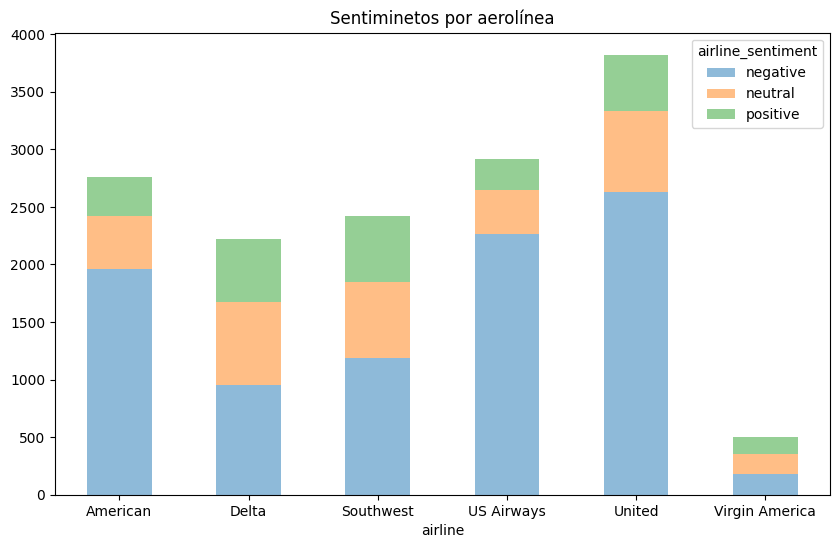

In [9]:
# Plot con cuenta de tweets por cada aerolínea y sentimiento
pd.crosstab(index = tweets["airline"],columns = tweets["airline_sentiment"]).plot(kind='bar',figsize=(10, 6),alpha=0.5,rot=0,stacked=True,title="Sentiminetos por aerolínea")

### Liberias y Variables de interés y predicción

In [10]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from nltk.stem.snowball import SnowballStemmer
from nltk.stem import WordNetLemmatizer

In [12]:
# Separación de variables predictoras (X) y de variable de interés (y)
X = tweets['text']
y = tweets['airline_sentiment'].map({'negative':-1,'neutral':0,'positive':1})

In [13]:
# Separación de datos en set de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 1 - Uso de CountVectorizer

En la celda 1 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [14]:
# Celda 1
vect_A = CountVectorizer()
X_dtm_A = vect_A.fit_transform(X_train)

In [15]:
# Se declara el modelo de clasificación de Random Forest y se entrena con el set de entrenamiento
rf_A = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_A.fit(X_dtm_A, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [40]:
# Se evalua el modelo con el set de test
from sklearn.metrics import accuracy_score
X_dtm_A_test = vect_A.transform(X_test)
y_pred_A = rf_A.predict(X_dtm_A_test)

# Se calcula el accuracy
accuracy_A = accuracy_score(y_test, y_pred_A)
print(f'Accuracy: {accuracy_A:.4f}')

# Se calcula el F1 score
from sklearn.metrics import f1_score
f1_A = f1_score(y_test, y_pred_A, average='weighted')
print(f'F1 Score: {f1_A:.4f}')

Accuracy: 0.7711
F1 Score: 0.7473


### Punto 2 - Eliminación de Stopwords

En la celda 2 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer, **eliminen stopwords** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [17]:
# Celda 2
vect_B = CountVectorizer(stop_words='english')
X_dtm_B = vect_B.fit_transform(X_train)

In [18]:
# Se declara el modelo de clasificación de Random Forest y se entrena con el set de entrenamiento
rf_B = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_B.fit(X_dtm_B, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [41]:
X_dtm_B_test = vect_B.transform(X_test)
y_pred_B = rf_B.predict(X_dtm_B_test)

# Se calcula el accuracy
accuracy_B = accuracy_score(y_test, y_pred_B)
print(f'Accuracy: {accuracy_B:.4f}')

# Se calcula el F1 score
from sklearn.metrics import f1_score
f1_B = f1_score(y_test, y_pred_B, average='weighted')
print(f'F1 Score: {f1_B:.4f}')

Accuracy: 0.7618
F1 Score: 0.7548


### Punto 3 - Lematización con verbos

En la celda 3 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer, **lematizen el texto con verbos** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [22]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\lumor\AppData\Roaming\nltk_data...


True

In [23]:
# Celda 3
# Definición de la función que tenga como parámetro texto y devuelva una lista de lemas
wordnet_lemmatizer = WordNetLemmatizer()
def split_into_lemmas(text):
    text = text.lower()
    words = text.split()
    return [wordnet_lemmatizer.lemmatize(word, pos='v') for word in words]

vect_C = CountVectorizer(analyzer=split_into_lemmas)
X_dtm_C = vect_C.fit_transform(X_train)

In [24]:
# Se declara el modelo de clasificación de Random Forest y se entrena con el set de entrenamiento
rf_C = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_C.fit(X_dtm_C, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [42]:
X_dtm_C_test = vect_C.transform(X_test)
y_pred_C = rf_C.predict(X_dtm_C_test)

# Se calcula el accuracy
accuracy_C = accuracy_score(y_test, y_pred_C)
print(f'Accuracy: {accuracy_C:.4f}')

# Se calcula el F1 score
from sklearn.metrics import f1_score
f1_C = f1_score(y_test, y_pred_C, average='weighted')
print(f'F1 Score: {f1_C:.4f}')

Accuracy: 0.7612
F1 Score: 0.7324


### Punto 4 - Multiples técnicas

En la celda 4 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer, eliminen stopwords, lematizen el texto con verbos** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [26]:
# Celda 4
vect_D = CountVectorizer(stop_words='english', analyzer=split_into_lemmas)
X_dtm_D = vect_D.fit_transform(X_train)

In [27]:
# Se declara el modelo de clasificación de Random Forest y se entrena con el set de entrenamiento
rf_D = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_D.fit(X_dtm_D, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [43]:
X_dtm_D_test = vect_D.transform(X_test)
y_pred_D = rf_D.predict(X_dtm_D_test)

# Se calcula el accuracy
accuracy_D = accuracy_score(y_test, y_pred_D)
print(f'Accuracy: {accuracy_D:.4f}')

# Se calcula el F1 score
from sklearn.metrics import f1_score
f1_D = f1_score(y_test, y_pred_D, average='weighted')
print(f'F1 Score: {f1_D:.4f}')

Accuracy: 0.7612
F1 Score: 0.7324


### Punto 5 - Comparación y análisis de resultados

En la celda 5 comparen los resultados obtenidos de los diferentes modelos (random forest) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

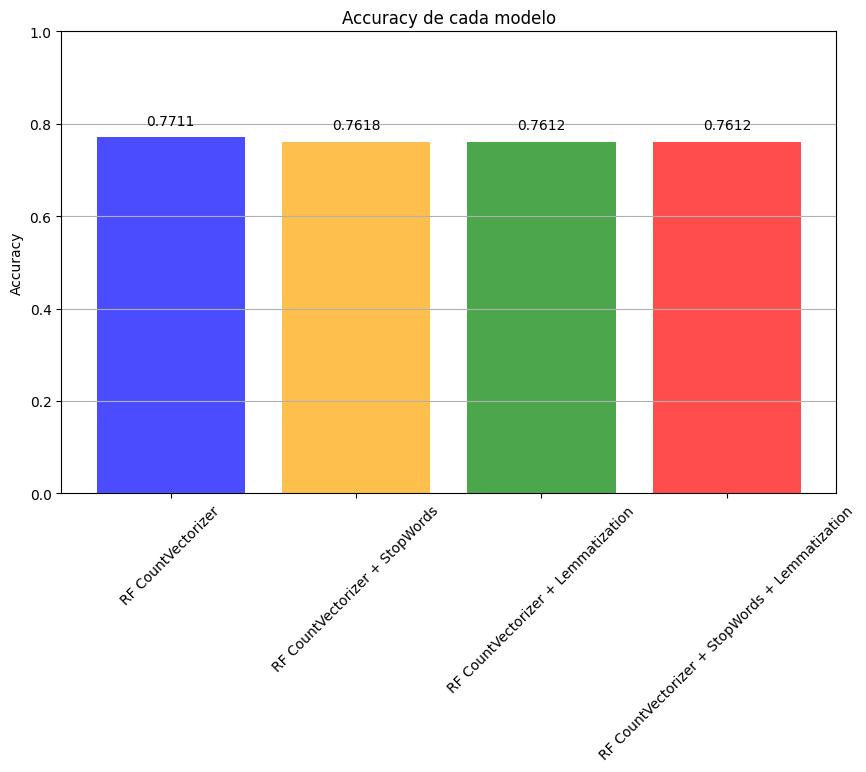

In [44]:
# Celda 5
# Generar grafica compartiva de los accuracy de cada celda
import matplotlib.pyplot as plt

# Definición de los nombres de las celdas y los accuracy
cell_names = ['RF CountVectorizer', 'RF CountVectorizer + StopWords', 'RF CountVectorizer + Lemmatization', 'RF CountVectorizer + StopWords + Lemmatization']
accuracy_values = [accuracy_A, accuracy_B, accuracy_C, accuracy_D]

# Definición de la figura y el tamaño
plt.figure(figsize=(10, 6))
plt.title('Accuracy de cada modelo')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis='y')

bars = plt.bar(cell_names, accuracy_values, color=['blue', 'orange', 'green', 'red'], alpha=0.7)

# Añadir los valores encima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{height:.4f}', 
             ha='center', va='bottom', fontsize=10)

Algunas conclusiones de este caso son:

* El desempeño de los 4 modelos no varia de manera significativa.
* El leve deterioro del desempeño medido en el accuracy puede estar indicando que los procesos de preprocesamiento pueden estar eliminando palabras clave que afectan el sentido del texto restante.
* Visto desde otras metricas como el F-1 Score, el modelo con stopwords obtiene una ligera mejora con respecto a los otros modelos
* El accuracy es una buena metrica para datos balanceados, el set de datos analizado esta ligeramente desbalanceado con 9178 datos en la clase (-1); 3099 datos en la clase (0); y 2363 datos en la clase (1). Por lo que otras metricas deberian consultarse para obtener una mejor comprension del desempeño de los modelos.

Por otro lado, basados en el accuracy:
* El mejor modelo fue el modelo del punto 1 que usa CountVectorizer unicamente.
* Este mejor desempeño puede deberse a que el preprocemiento puede eliminar palabras que son determinantes para aprender el sentido del texto. Esto puede suceder para stopwords como "NO".
* Al lematizar con verbos se puede estar perdiendo matices temporales que pueden ayudar a detectar el sentido del comentario.
* El peor modelo es el modelo con lemmatizacion y el modelo con tecnicas multiples, ambos tienen un Accuracy de 0.7612
* La lemmatizacion usada reduce las palabras a verbos y esto puede estar afectando la capacidad de orientar el sentido verdadero.
* Estos resultados demuestran que el modelo base esta beneficiandose de la presencia de stopwords y de los tiempos verbales usados en los comentarios.

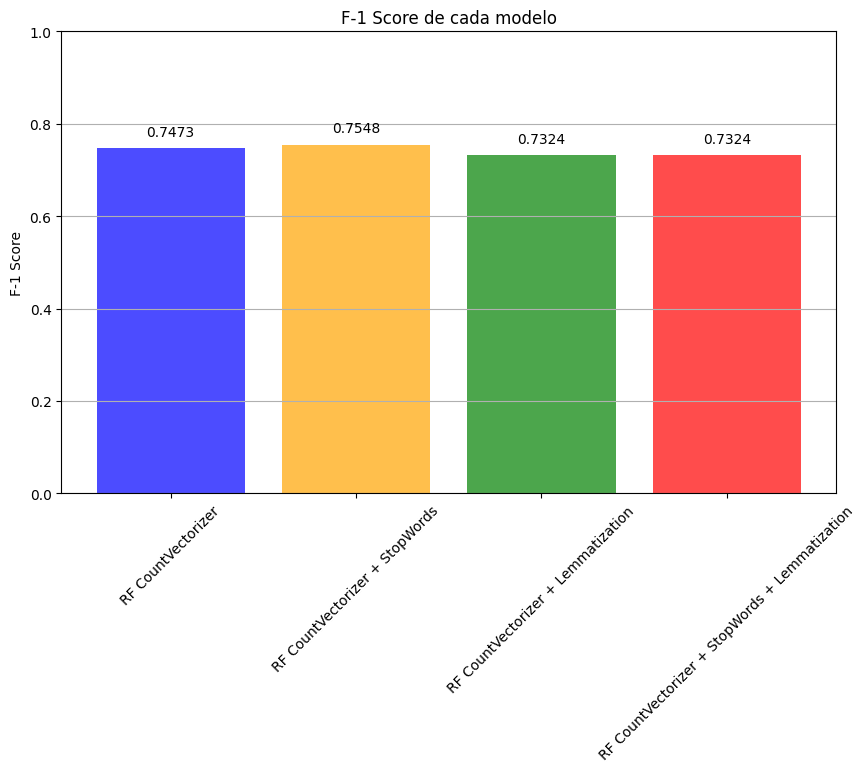

In [45]:
# Definición de los nombres de las celdas y los accuracy
cell_names = ['RF CountVectorizer', 'RF CountVectorizer + StopWords', 'RF CountVectorizer + Lemmatization', 'RF CountVectorizer + StopWords + Lemmatization']
accuracy_values = [f1_A, f1_B, f1_C, f1_D]

# Definición de la figura y el tamaño
plt.figure(figsize=(10, 6))
plt.title('F-1 Score de cada modelo')
plt.ylabel('F-1 Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis='y')

bars = plt.bar(cell_names, accuracy_values, color=['blue', 'orange', 'green', 'red'], alpha=0.7)

# Añadir los valores encima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{height:.4f}', 
             ha='center', va='bottom', fontsize=10)

In [46]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_A, digits=4))

              precision    recall  f1-score   support

          -1     0.7758    0.9634    0.8595      3085
           0     0.6915    0.4055    0.5112       984
           1     0.8373    0.4653    0.5981       763

    accuracy                         0.7711      4832
   macro avg     0.7682    0.6114    0.6563      4832
weighted avg     0.7683    0.7711    0.7473      4832



In [47]:
print(classification_report(y_test, y_pred_B, digits=4))

              precision    recall  f1-score   support

          -1     0.8194    0.8869    0.8518      3085
           0     0.5726    0.4929    0.5298       984
           1     0.7121    0.6029    0.6529       763

    accuracy                         0.7618      4832
   macro avg     0.7014    0.6609    0.6782      4832
weighted avg     0.7522    0.7618    0.7548      4832



In [48]:
print(classification_report(y_test, y_pred_C, digits=4))

              precision    recall  f1-score   support

          -1     0.7633    0.9689    0.8539      3085
           0     0.6798    0.3669    0.4766       984
           1     0.8519    0.4299    0.5714       763

    accuracy                         0.7612      4832
   macro avg     0.7650    0.5885    0.6340      4832
weighted avg     0.7603    0.7612    0.7324      4832



In [49]:
print(classification_report(y_test, y_pred_D, digits=4))

              precision    recall  f1-score   support

          -1     0.7633    0.9689    0.8539      3085
           0     0.6798    0.3669    0.4766       984
           1     0.8519    0.4299    0.5714       763

    accuracy                         0.7612      4832
   macro avg     0.7650    0.5885    0.6340      4832
weighted avg     0.7603    0.7612    0.7324      4832

